# 02 — Nettoyage & validation Olist (Phase 3)

Ce notebook exécute le pipeline de nettoyage (`src/cleaning/clean.py`) et de validation (`src/cleaning/validate_clean.py`), puis visualise le résultat.

**Aucune feature ML n'est calculée ici** (pas de colonne churn, pas de RFM) : ce sera l'objet de la Phase 5.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Le notebook est exécuté depuis notebooks/, donc la racine du projet est le
# dossier parent. On l'ajoute à sys.path pour pouvoir importer src.cleaning
# comme un package, exactement comme le font clean.py et validate_clean.py.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.cleaning import clean, validate_clean
from src.ingestion import config

pd.set_option("display.max_columns", None)

## 1. Avant nettoyage : `olist_merged.csv`

In [2]:
raw_df = clean.load_merged()
print("Shape :", raw_df.shape)
raw_df.isna().sum().sort_values(ascending=False)

Shape : (119143, 37)


review_comment_title             105154
review_comment_message            68898
order_delivered_customer_date      3421
product_category_name_english      2567
product_category_name              2542
product_photos_qty                 2542
product_name_lenght                2542
product_description_lenght         2542
order_delivered_carrier_date       2086
review_creation_date                997
review_id                           997
review_answer_timestamp             997
review_score                        997
product_width_cm                    853
product_weight_g                    853
product_length_cm                   853
product_height_cm                   853
freight_value                       833
seller_id                           833
product_id                          833
price                               833
shipping_limit_date                 833
order_item_id                       833
order_approved_at                   177
payment_type                          3


## 2. Exécution du pipeline de nettoyage

In [3]:
customers_df = clean.run_cleaning()
customers_df.shape

=== Nettoyage Olist - 2026-07-21T15:37:18 ===



Chargement : 119143 lignes x 37 colonnes
[ETAPE 1] Filtrage 'delivered' + order_purchase_timestamp non-null : 119143 -> 115723 lignes
[ETAPE 2] Suppression colonnes : 37 -> 33 colonnes | supprimees : ['review_comment_title', 'review_comment_message', 'order_approved_at', 'order_delivered_carrier_date']


[ETAPE 3] Conversion en datetime (errors='coerce') : ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'review_creation_date']
[ETAPE 4] review_score : 861 NaN combles avec la mediane (5.0)
[ETAPE 4] order_delivered_customer_date : 8 NaN laisses tels quels (commandes en transit)
[ETAPE 4] price : 0 lignes supprimees (prix manquant) -> 115723 lignes
[ETAPE 4] payment_value : 3 NaN combles avec price


[ETAPE 5] Agregation par customer_unique_id : 115723 lignes (93358 clients) -> 93358 clients
[ETAPE 5] Sauvegarde : C:\Users\amenm\Desktop\Customer Intelligence Platform\Customer-Intelligence-Platform-End-to-End-Data-AI-Engineering-Project\data\processed\olist_customers_clean.csv
[ETAPE 6] total_spent : Q1=63.83 Q3=202.64 IQR=138.81 seuil=619.06 -> 5201 outliers detectes
[ETAPE 6] total_spent : 20 outliers les plus extremes (sur 5201) :
                     customer_unique_id  total_orders  total_spent  avg_review_score    first_order_date     last_order_date      most_frequent_category customer_state
3724   0a0a92112bd4c708ca5fde585afaa872             1    109312.64               1.0 2017-09-29 15:24:52 2017-09-29 15:24:52             fixed_telephony             RJ
38579  698e1cf81d01a3d389d96145f7fa6df8             1     45256.00               5.0 2017-08-23 09:22:34 2017-08-23 09:22:34                        auto             GO
71566  c402f431464c72e27330a67f7b94d4fb             1  

(93358, 8)

## 3. Validation du dataset client nettoyé

In [4]:
validate_clean.run_validation()

=== Validation olist_customers_clean.csv ===
Shape : (93358, 8)
Toutes les verifications sont passees.

--- Statistiques descriptives ---
                          count unique                               top  \
customer_unique_id        93358  93358  0000366f3b9a7992bf8c76cfdf3221e2   
total_orders            93358.0    NaN                               NaN   
total_spent             93358.0    NaN                               NaN   
avg_review_score        93358.0    NaN                               NaN   
first_order_date          93358    NaN                               NaN   
last_order_date           93358    NaN                               NaN   
most_frequent_category    92079     71                    bed_bath_table   
customer_state            93358     27                                SP   

                         freq                        mean  \
customer_unique_id          1                         NaN   
total_orders              NaN                     1.033

## 4. Après nettoyage : vue d'ensemble

In [5]:
print("Shape :", customers_df.shape)
customers_df.describe(include="all").T

Shape : (93358, 8)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
customer_unique_id,93358,93358,0000366f3b9a7992bf8c76cfdf3221e2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_orders,93358.0,NaN,NaN,NaN,1.03342,1.0,1.0,1.0,1.0,15.0,0.209097
total_spent,93358.0,NaN,NaN,NaN,212.966002,9.59,63.83,113.14,202.6375,109312.64,646.223541
avg_review_score,93358.0,NaN,NaN,NaN,4.159056,1.0,4.0,5.0,5.0,5.0,1.277958
first_order_date,93358,NaN,NaN,NaN,2018-01-01 12:18:32.380503,2016-09-15 12:16:38,2017-09-13 15:41:22.500000,2018-01-20 06:48:07,2018-05-05 14:13:38.250000,2018-08-29 15:00:37,NaN
last_order_date,93358,NaN,NaN,NaN,2018-01-04 03:47:36.045363,2016-09-15 12:16:38,2017-09-17 18:25:15,2018-01-23 00:12:12.500000,2018-05-07 17:22:34.750000,2018-08-29 15:00:37,NaN
most_frequent_category,92079,71,bed_bath_table,8899,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_state,93358,27,SP,39150,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Visualisations

`customers_df` est déjà agrégé par `customer_unique_id` (une ligne par client), donc aucune déduplication supplémentaire n'est nécessaire ici.

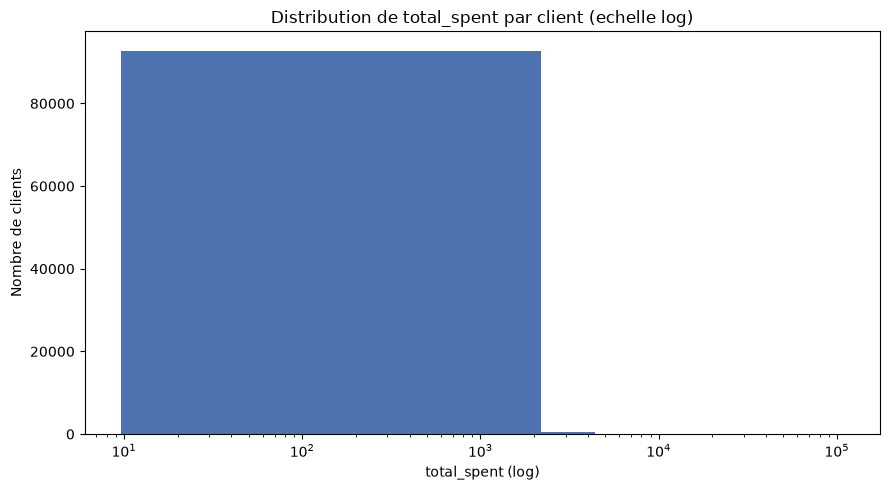

In [6]:
# --- Distribution de total_spent (histogramme, echelle log sur l'axe x) ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(customers_df["total_spent"], bins=50, color="#4C72B0")
ax.set_xscale("log")
ax.set_title("Distribution de total_spent par client (echelle log)")
ax.set_xlabel("total_spent (log)")
ax.set_ylabel("Nombre de clients")
plt.tight_layout()
plt.show()

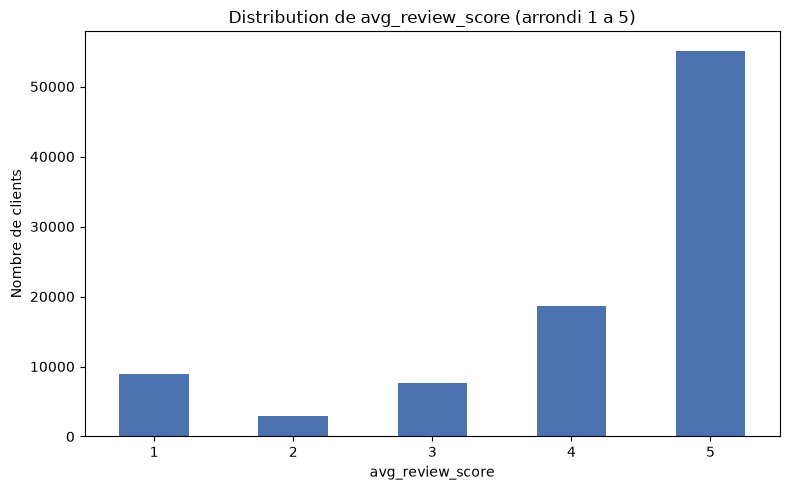

In [7]:
# --- Distribution de avg_review_score (barplot, valeurs 1 a 5) ---
review_buckets = (
    customers_df["avg_review_score"]
    .round()
    .value_counts()
    .reindex([1, 2, 3, 4, 5], fill_value=0)
)

fig, ax = plt.subplots(figsize=(8, 5))
review_buckets.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Distribution de avg_review_score (arrondi 1 a 5)")
ax.set_xlabel("avg_review_score")
ax.set_ylabel("Nombre de clients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\amenm\AppData\Local\Temp\ipykernel_29628\1780698112.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(customers_df["total_spent"], vert=True)


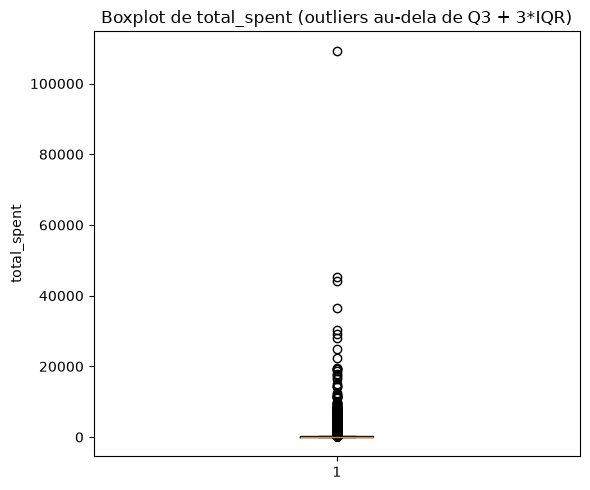

In [8]:
# --- Outliers sur total_spent (boxplot) ---
fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(customers_df["total_spent"], vert=True)
ax.set_title("Boxplot de total_spent (outliers au-dela de Q3 + 3*IQR)")
ax.set_ylabel("total_spent")
plt.tight_layout()
plt.show()